# EDA For Youtube Virality Classifyer

## Get, Load, and Prepare Data

In [35]:
import os
import shutil
import subprocess
import pandas as pd
import fastparquet
import kagglehub

DATA_DIR = "data"
CSV_FILE = os.path.join(DATA_DIR, "trending_yt_videos_113_countries.csv")
PARQUET_FILE = os.path.join(DATA_DIR, "youtube_data.parquet")
os.makedirs(DATA_DIR, exist_ok=True)

In [36]:
if not os.path.exists(PARQUET_FILE) and not os.path.exists(CSV_FILE):
    print("Dataset not found locally. Downloading from Kaggle...")
    cache_path = kagglehub.dataset_download("asaniczka/trending-youtube-videos-113-countries/versions/852")
    
    # Find the CSV in the Kaggle cache and copy it to our data folder
    for file in os.listdir(cache_path):
        if file.endswith(".csv"):
            shutil.copy(os.path.join(cache_path, file), CSV_FILE)
            print(f"Successfully moved CSV to {CSV_FILE}")
else:
    print("CSV or Parquet already exists! Skipping download...........")

CSV or Parquet already exists! Skipping download...........


In [37]:
if not os.path.exists(PARQUET_FILE):
    print("Parquet file not found! preprocessing.........")
    result = subprocess.run(["python3", "process.py"], capture_output=True, text=True)
    
    if result.returncode == 0:
        print(result.stdout)
    else:
        print(result.stderr)
else:
    print("Parquet already exists! Ready!!!!")

Parquet already exists! Ready!!!!


## Data Cleaning

* De-duplicate an anaylize data head

In [ ]:
import polars as pl

df = pl.read_parquet(PARQUET_FILE)


df = df.sort("snapshot_date")
df = df.unique(subset=["video_id"], keep="last")


df = df.to_pandas()

print(f"DataFrame Shape: {df.shape}")
df.head()

DataFrame Shape: (457143, 19)


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,video_id,channel_id,video_tags,kind,publish_date,langauge,publish_day,like_tier
0,HIGHLIGHTS | Real Madrid 2-0 Villarreal | LaL...,Real Madrid,34,-12,16,2024-10-07 00:00:00+00:00,IN,1202660,42221,1407,Real Madrid will head into the international b...,q8gfkpcbvrQ,UCWV3obpZVGgJ3j9FVhEjF2Q,"Real Madrid, Madrid, Real Madrid CF, Madridist...",youtube#video,2024-10-05 00:00:00+00:00,es,Saturday,pretty_viral
1,Lagu Kenangan Ebiet G Ade Terbaik | Karya Terb...,Joko Musik,42,8,8,2025-08-10 00:00:00+00:00,ID,17981,0,29,Lagu Kenangan Ebiet G Ade Terbaik | Karya Terb...,mtvH-0ONpeQ,UC9YCI4Xe-cvPlaVY3x59LRw,"ebiet g ade full album religi, lagu ebiet g ad...",youtube#video,2025-08-09 00:00:00+00:00,id,Saturday,a_little_viral
2,99-күн орманда Той жасадық | Бұғыны шақырмадық!,AJIuKZ,12,-4,38,2025-12-07 00:00:00+00:00,KZ,403885,12461,1281,✅Видео Ұнаса ЛАЙК және Каналға тіркелейік дост...,emfD82tkEKo,UCOBv083-6jYmwUVp_VUPolA,"AJluKZ, АЛИКЗ, AJIuKZ, alikz, Али кз, Роблокс ...",youtube#video,2025-12-01 00:00:00+00:00,kk,Monday,pretty_viral
3,World Cup Paavangal | Parithabangal,Parithabangal,31,-8,19,2023-11-24 00:00:00+00:00,IN,2144394,159004,4370,#parithabangal #worldcuppaavangal #paavangal #...,Pl-42Gumrt4,UCueYcgdqos0_PzNOq81zAFg,"parithabangal, bypass parithabangal, paridhaba...",youtube#video,2023-11-21 00:00:00+00:00,ta,Tuesday,really_viral
4,Asi es la CIUDAD del PAPA LEÓN XIV en PERÚ: Ch...,Oscar Alejandro,49,-5,-41,2025-05-28 00:00:00+00:00,EC,626212,26251,1989,👉🏽VPN Surfshark: Entra a https://surfshark.com...,eusSr8sMqgc,UCXCexi3Dc5eDLsNlxacuc6g,"Oscar Alejandro, Oscar Alejandro youtuber, Osc...",youtube#video,2025-05-18 00:00:00+00:00,es-419,Sunday,pretty_viral


Check data types from process.py load properly

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 457143 entries, 0 to 457142
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   title            457143 non-null  str                
 1   channel_name     457143 non-null  category           
 2   daily_rank       457143 non-null  uint8              
 3   daily_movement   457143 non-null  int16              
 4   weekly_movement  457143 non-null  int16              
 5   snapshot_date    457143 non-null  datetime64[us, UTC]
 6   country          457143 non-null  category           
 7   view_count       457143 non-null  int64              
 8   like_count       457143 non-null  int32              
 9   comment_count    457143 non-null  int32              
 10  description      457143 non-null  str                
 11  video_id         457143 non-null  str                
 12  channel_id       457143 non-null  str                
 13  video_tags

In [40]:
df.shape
df.describe()

,daily_rank,daily_movement,weekly_movement,view_count,like_count,comment_count
count,457143.000000,457143.000000,457143.000000,4.571430e+05,4.571430e+05,4.571430e+05
mean,37.246824,-0.812083,8.226747,1.568506e+06,4.675782e+04,1.372158e+03
std,11.759504,16.586358,18.054480,6.839126e+06,2.093932e+05,1.152355e+04
min,1.000000,-49.000000,-49.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,30.000000,-11.000000,2.000000,9.063200e+04,2.187000e+03,8.800000e+01
50%,41.000000,-3.000000,8.000000,2.480130e+05,6.942000e+03,3.310000e+02
75%,47.000000,8.000000,19.000000,7.354745e+05,2.232050e+04,1.040000e+03
max,50.000000,49.000000,49.000000,4.621179e+08,1.576806e+07,6.491355e+06


In [41]:
df.sample(5)


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,video_id,channel_id,video_tags,kind,publish_date,langauge,publish_day,like_tier
347409,"10,000 Villager Pergi Liburan !!!",RemanRHN,48,-14,2,2025-12-04 00:00:00+00:00,MY,415934,13610,749,Inspired By : GroxMC & NotSafe \n\n****\nHari ...,UOmpUSKpE-o,UC-k9YuHccYMQJ4BgMKWuYEQ,"groxmc, minecraft, minecraft 1000 mob, 1000 mo...",youtube#video,2025-11-30 00:00:00+00:00,en-US,Sunday,pretty_viral
227103,Vybz Kartel - Nawmal Again (official audio),VybzKartelVEVO,41,-1,-29,2025-10-17 00:00:00+00:00,JM,492447,23428,2484,"#VybzKartel #NawmalAgain #Dancehall\n\n""NAWMAL...",ZBwhtdLAKg8,UCeRe0C1x1w8We6ghjVn4M5w,"popcaan, teflon fire stick, pamputtae shake su...",youtube#video,2025-10-02 00:00:00+00:00,en,Thursday,pretty_viral
455758,"Танковые новости: Обновление 1.35, переработка...",Мир Танков. Официальный видеоканал,32,18,18,2025-06-11 00:00:00+00:00,RU,51855,2844,470,"Танкисты, вашему вниманию сладкий как черешня,...",e97EFtTpzCE,UCVnah-S-sByndtg9cHBxlOA,"мир танков, танк, танки, онлайн, леста, lesta,...",youtube#video,2025-06-10 00:00:00+00:00,ru,Tuesday,a_little_viral
419047,Fade Like a Dream (Radio Edit),cpl horizon - Topic,46,-11,4,2025-10-28 00:00:00+00:00,UA,281889,2639,0,Provided to YouTube by DistroKid\n\nFade Like ...,5Uu_JC2HEu4,UCt9W1LMkEbOKJu0VkyLLbuA,"cpl horizon, ralf oertel, Fade Like a Dream (R...",youtube#video,2025-10-17 00:00:00+00:00,en,Friday,a_little_viral
286330,Marc Seguí - Tiroteo Remix ft. Rauw Alejandro ...,Moodify,41,-28,9,2025-09-04 00:00:00+00:00,BO,165951,283,4,🎵 ¡Gracias por escuchar en Moodify! 🌈\nNo olvi...,W72_Y-TtrHk,UCJjgs-dhJ2rP3z6AiTo2Vuw,"sub. español, lyrics, letras, video lyrics, mo...",youtube#video,2025-08-31 00:00:00+00:00,es,Sunday,a_little_viral


In [42]:
df.isna().sum()


title              0
channel_name       0
daily_rank         0
daily_movement     0
weekly_movement    0
snapshot_date      0
country            0
view_count         0
like_count         0
comment_count      0
description        0
video_id           0
channel_id         0
video_tags         0
kind               0
publish_date       0
langauge           0
publish_day        0
like_tier          0
dtype: int64

In [43]:
df.duplicated().sum()


np.int64(0)

### Results from data cleaning

* Data is pretty clean, once we delete duplicate videos we still have well over a quarter million rows so that is pretty good

## Data Exploration

* Check the date range of the dataset

In [44]:
df['publish_date'] = pd.to_datetime(df['publish_date'])
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

# Get the oldest date
oldest_date = df['publish_date'].min()

# Get the newest date
newest_date = df['publish_date'].max()

print(f"Oldest: {oldest_date}")
print(f"Newest: {newest_date}")

Oldest: 2023-09-20 02:22:46+00:00
Newest: 2026-02-18 00:00:00+00:00


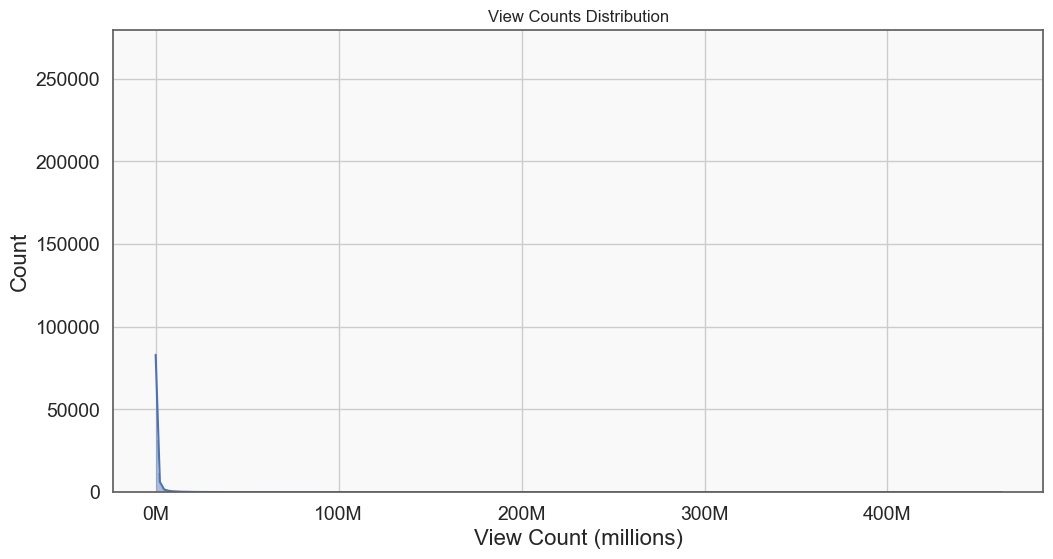

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


df['publish_month'] = df['publish_date'].dt.month
df['publish_day'] = df['publish_date'].dt.day
df['publish_year'] = df['publish_date'].dt.year

plt.figure(figsize=(12,6))
sns.histplot(df['view_count'], kde=True)
plt.title('View Counts Distribution')

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('View Count (millions)', fontsize=16)
plt.ylabel('Count', fontsize=16)

plt.show()

#### These graphs show a heavy right skew so we will view them logarithmically

/Users/mccayruddick/Documents/Computer_Science/CSC487_Final/DeeplearningFinalUwU/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


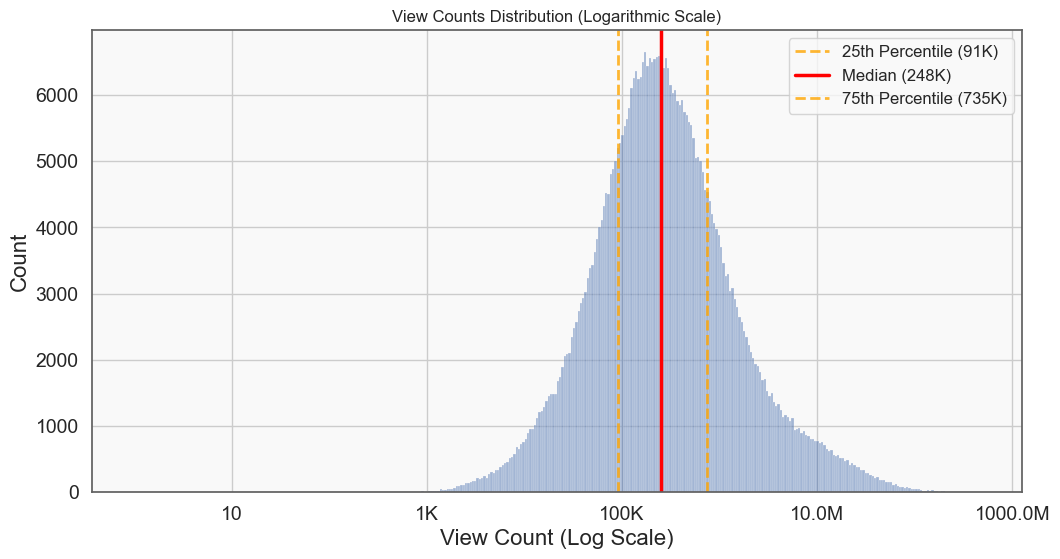

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.figure(figsize=(12, 6))
ax = plt.gca() 

sns.histplot(df['view_count'], kde=True, log_scale=True)

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

# 1. Calculate the quantiles
q25 = df['view_count'].quantile(0.25)
median = df['view_count'].median() # Same as quantile(0.50)
q75 = df['view_count'].quantile(0.75)

# 2. Draw the vertical lines (axvline)
ax.axvline(q25, color='orange', linestyle='--', linewidth=2, alpha=0.8, 
           label=f'25th Percentile ({human_readable_format(q25, None)})')
           
ax.axvline(median, color='red', linestyle='-', linewidth=2.5, 
           label=f'Median ({human_readable_format(median, None)})')
           
ax.axvline(q75, color='orange', linestyle='--', linewidth=2, alpha=0.8, 
           label=f'75th Percentile ({human_readable_format(q75, None)})')

plt.legend(fontsize=12)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('View Count (Log Scale)', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.title('View Counts Distribution (Logarithmic Scale)')

plt.show()

This graph demonstrates our View Count is normally distriibuted, so that was very exciting. However we still want to look at like counts as that is the data we will be classifying

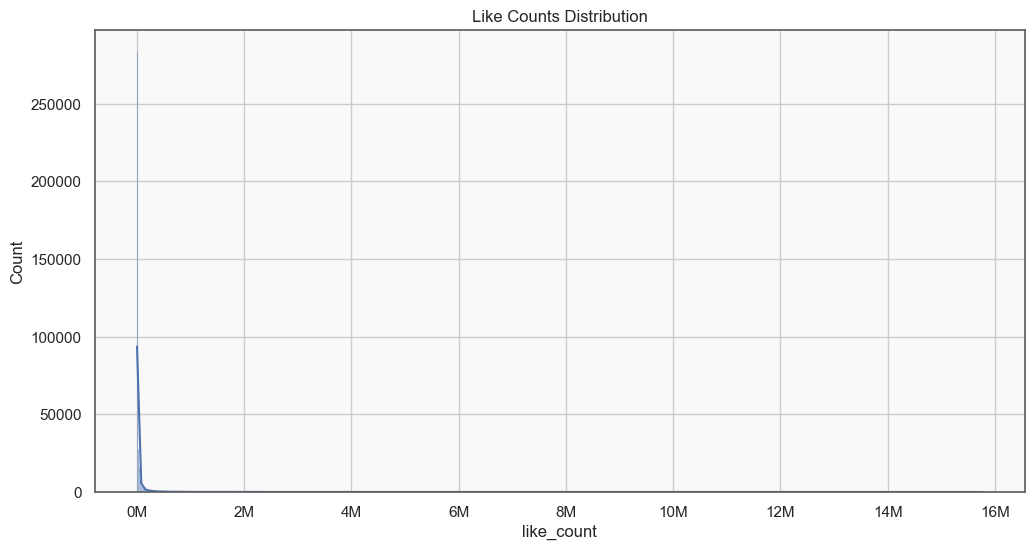

In [49]:
plt.figure(figsize=(12, 6))
ax = plt.gca() 
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

sns.histplot(df['like_count'], kde=True)
plt.title('Like Counts Distribution')
plt.show()

#### This shows the same distribution as the View Count so we will log it again

/Users/mccayruddick/Documents/Computer_Science/CSC487_Final/DeeplearningFinalUwU/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


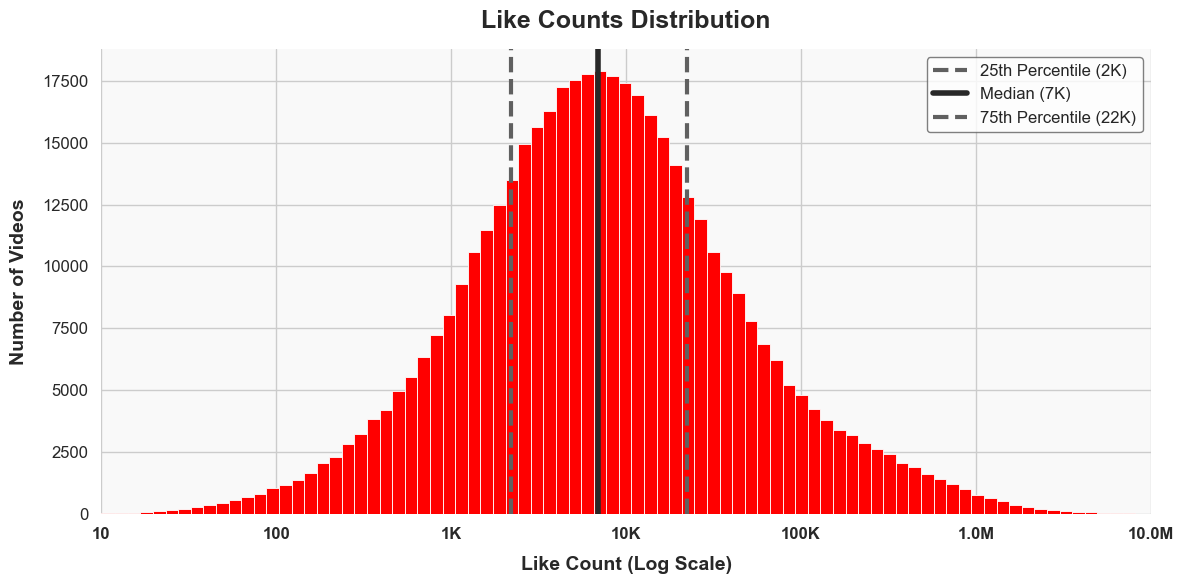

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

yt_red = '#FF0000'
yt_black = '#282828'
yt_gray = '#F9F9F9'
yt_dark_gray = '#606060'

sns.set_theme(style="whitegrid", rc={"axes.facecolor": yt_gray, "figure.facecolor": "white", "axes.edgecolor": yt_dark_gray})

plt.figure(figsize=(12, 6))
ax = plt.gca() 

sns.histplot(df['like_count'], kde=True, log_scale=True, bins=100, color=yt_red, edgecolor='white', alpha=1.0)

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.xlim(10, 1e7)

q25 = df['like_count'].quantile(0.25)
median = df['like_count'].median() 
q75 = df['like_count'].quantile(0.75)

ax.axvline(q25, color=yt_dark_gray, linestyle='--', linewidth=3, 
           label=f'25th Percentile ({human_readable_format(q25, None)})')
           
ax.axvline(median, color=yt_black, linestyle='-', linewidth=4, 
           label=f'Median ({human_readable_format(median, None)})')
           
ax.axvline(q75, color=yt_dark_gray, linestyle='--', linewidth=3, 
           label=f'75th Percentile ({human_readable_format(q75, None)})')

plt.legend(fontsize=12, frameon=True, facecolor='white', edgecolor=yt_dark_gray)

plt.xticks(fontsize=12, fontweight='bold', color=yt_black)
plt.yticks(fontsize=12, color=yt_black)
plt.xlabel('Like Count (Log Scale)', fontsize=14, fontweight='bold', color=yt_black, labelpad=10)
plt.ylabel('Number of Videos', fontsize=14, fontweight='bold', color=yt_black, labelpad=10)
plt.title('Like Counts Distribution', fontsize=18, fontweight='bold', color=yt_black, pad=15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### On a logarithmic scale, we can see that it's much closer to being normally distributed. We will use these percentiles shown as our data buckets. Also the graph is beautiful so we can place it in our presentation

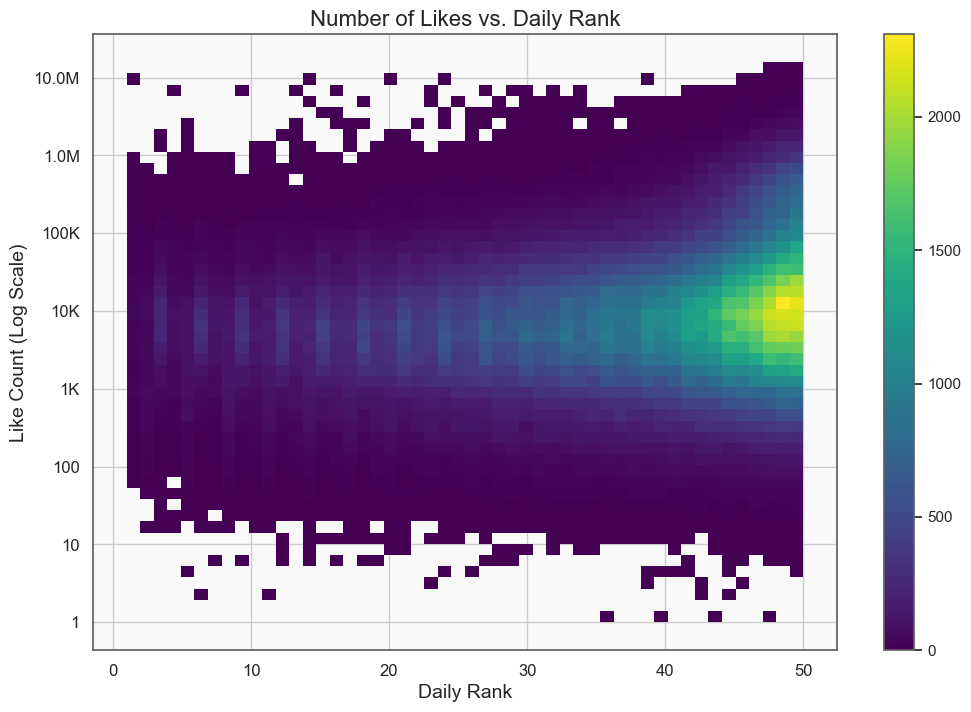

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np

plt.figure(figsize=(12, 8))

df_filtered = df[df['like_count'] > 0]

sns.histplot(
    data=df_filtered, 
    x='daily_rank', 
    y='like_count', 
    log_scale=(False, True),
    bins=50, 
    cbar=True,
    cmap='viridis'
)

ax = plt.gca()

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.title('Number of Likes vs. Daily Rank', fontsize=16)
plt.xlabel('Daily Rank', fontsize=14)
plt.ylabel('Like Count (Log Scale)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

Since the data shows the daily rank, this heatmap shows us were videos generally fall in that ranking vs how their like count is. Evidently, The majority of the videos, when de-duplicated, fall in the 50th rank with the median amount of likes. Where rank 1 seems to contain more unicorns of videos and we want to be able to classify those.

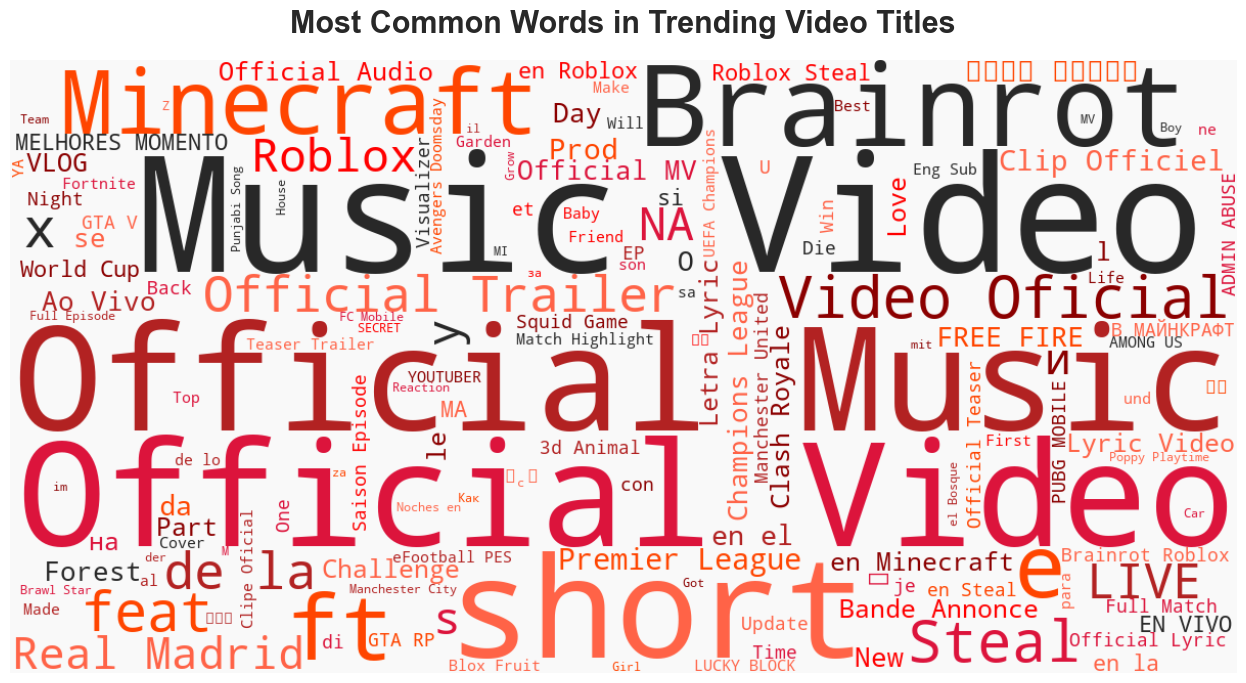

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import random


yt_colors_varied = [
    '#FF0000', # Pure Red
    '#DC143C', # Crimson
    '#B22222', # Fire Brick
    '#8B0000', # Dark Red
    '#FF4500', # Orange Red
    '#FF6347', # Tomato
    '#282828'  # YouTube Black
]

def yt_color_func_varied(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(yt_colors_varied)

wordcloud_varied = WordCloud(
    width=1200, 
    height=600, 
    background_color='#F9F9F9',
    color_func=yt_color_func_varied, 
    random_state=42
).generate(text)

plt.figure(figsize=(15, 7), facecolor='white')
plt.imshow(wordcloud_varied, interpolation='bilinear')
plt.axis('off')

plt.title("Most Common Words in Trending Video Titles", fontsize=22, fontweight='bold', color='#282828', pad=20)

plt.tight_layout()
plt.show()

We will be using BoW, TF-IDF, and RNN as well as Categorical features so this word cloud is to show what the top videos most commonly have in them.

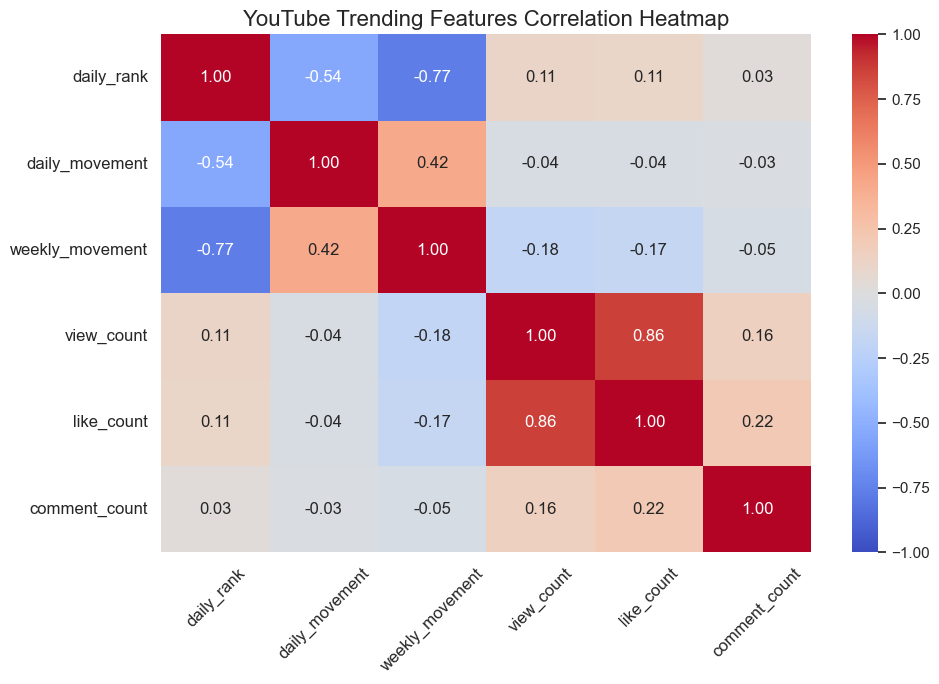

In [53]:
corr_df = df[["daily_rank", "daily_movement", "weekly_movement", "view_count", "like_count", "comment_count"]]

corr_matrix = corr_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("YouTube Trending Features Correlation Heatmap", fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

Looking at this heatmap, we see there is high positive linear correlation between features view_count and like_count. There's also a moderately positive correlation between daily_movement and weekly_movement. This means that as view count increases, so does like count and vice versa. And when there's more daily movement, that will also help weekly movement increase as well.

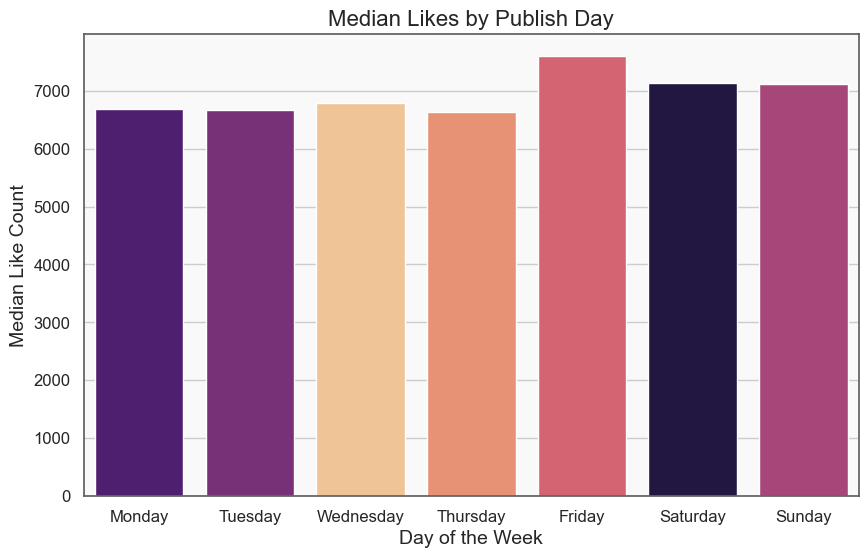

In [54]:
import pandas as pd

df['publish_day_of_week'] = df['publish_date'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df, 
    x='publish_day_of_week', 
    y='like_count', 
    order=days_order,
    estimator='median',
    errorbar=None,
    hue='publish_day_of_week',
    palette='magma',
    legend=False
)

plt.title('Median Likes by Publish Day', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Median Like Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

We can see that the tendency of the day that has most number of likes is Friday, though the average median like count for the seven days seem to be pretty consistent this may be useful as a feature so we will add it to our dataset parquet.

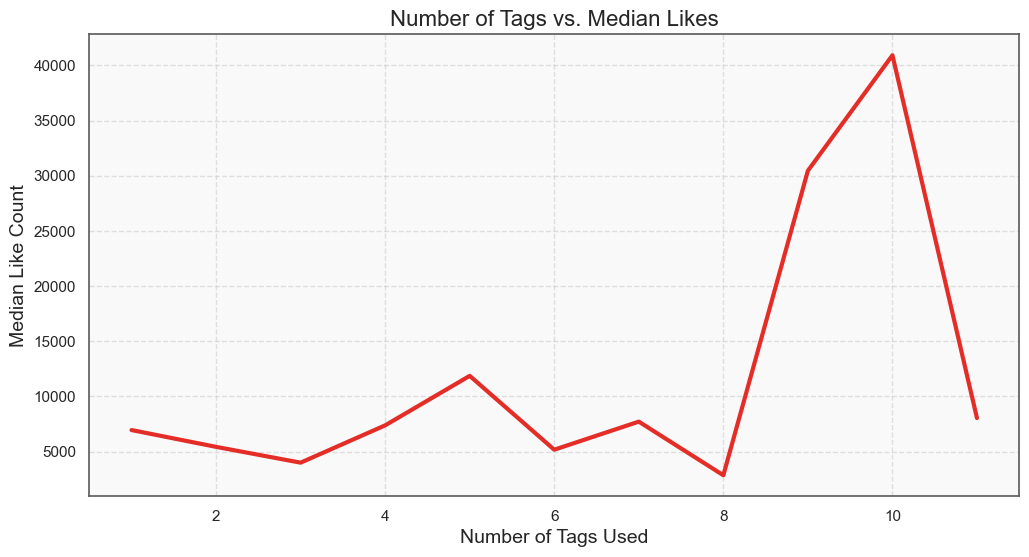

In [55]:
import numpy as np

df['tag_count'] = df['video_tags'].astype(str).str.split('|').str.len().fillna(0)
tag_grouped = df.groupby('tag_count')['like_count'].median().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=tag_grouped, 
    x='tag_count', 
    y='like_count', 
    linewidth=3,
    color='#e52d27'
)

plt.title('Number of Tags vs. Median Likes', fontsize=16)
plt.xlabel('Number of Tags Used', fontsize=14)
plt.ylabel('Median Like Count', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Based on this graph we can see the Number of Tags on high preforming videos is often round 9-10. We will also have this as a column in our dataset that could give us some high signal.

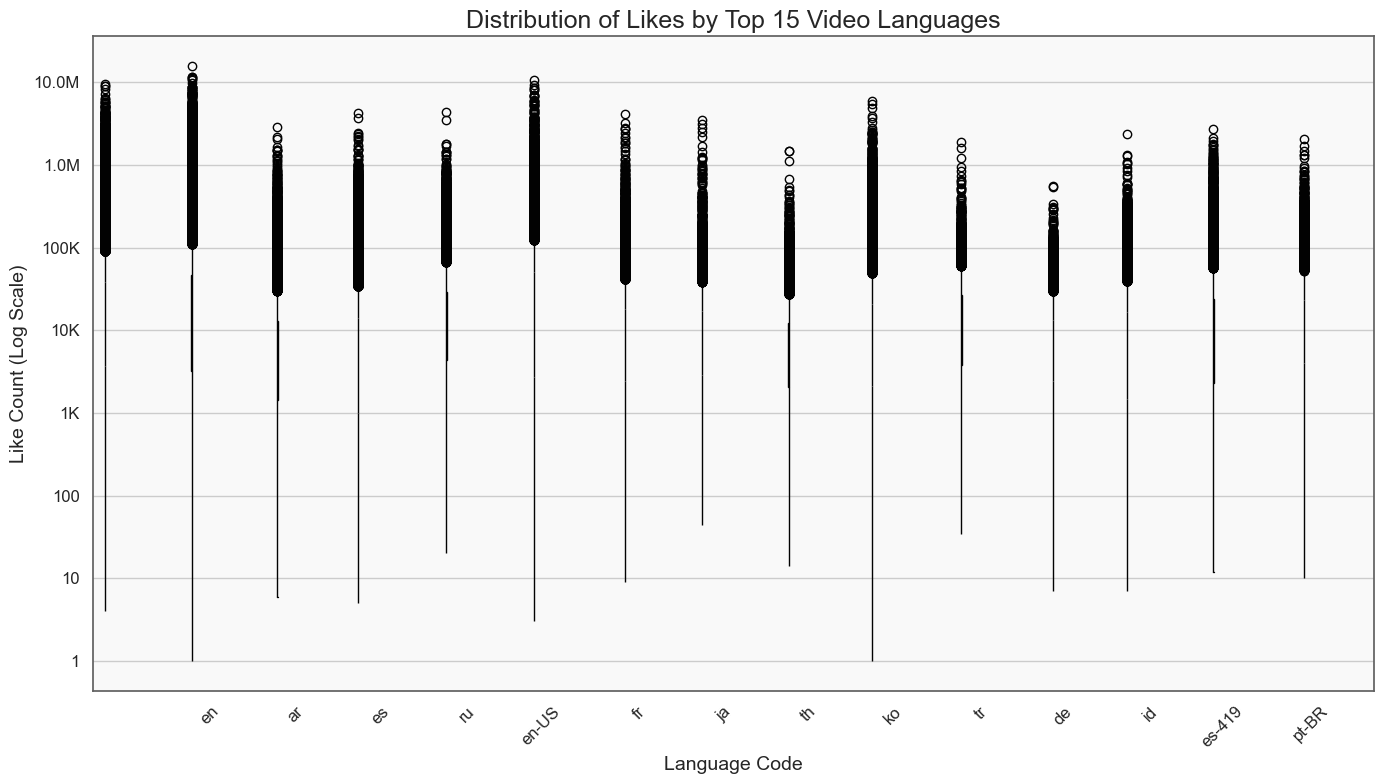

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

top_15_languages = df['langauge'].value_counts().nlargest(15).index
df_filtered = df[(df['langauge'].isin(top_15_languages)) & (df['like_count'] > 0)]

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df_filtered, 
    x='langauge', 
    y='like_count', 
    order=top_15_languages,
    hue='langauge',
    palette='magma',
    legend=False
)

ax = plt.gca()

ax.set_yscale('log')

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.title('Distribution of Likes by Top 15 Video Languages', fontsize=18)
plt.xlabel('Language Code', fontsize=14)
plt.ylabel('Like Count (Log Scale)', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

There aren't huge differences in like counts based on languages

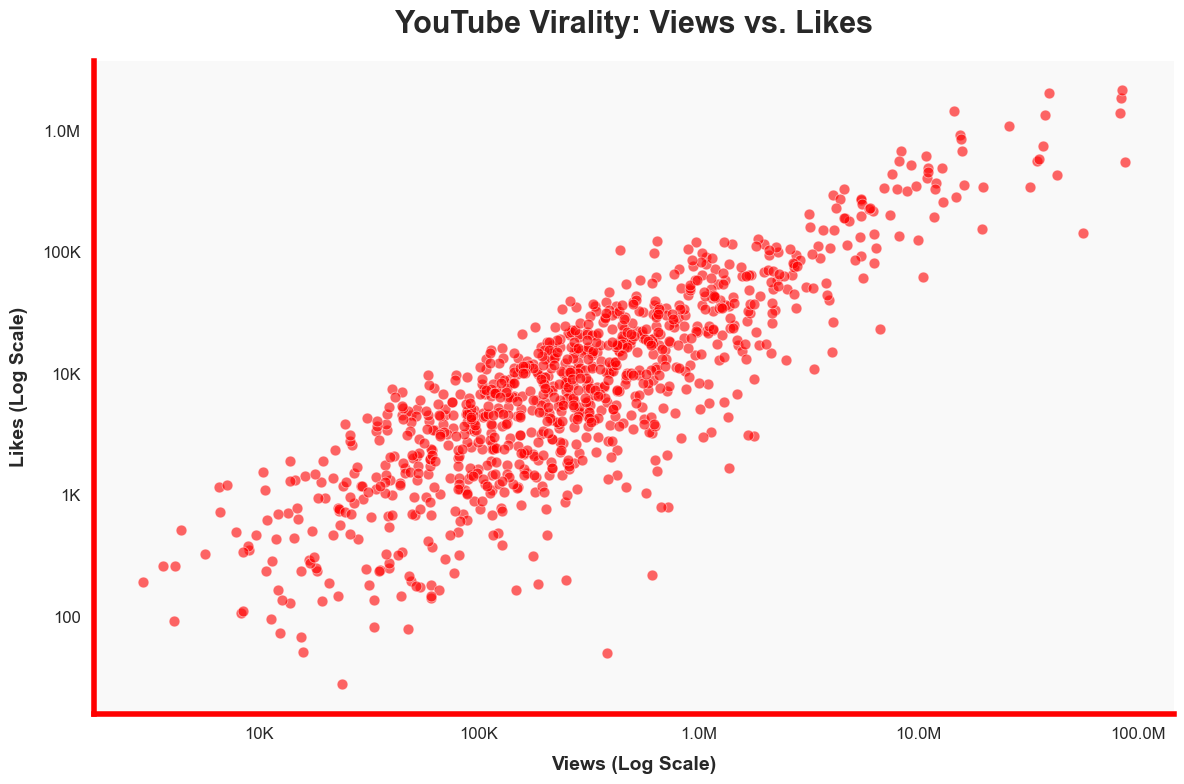

In [79]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

df_plot = df[df['like_tier'].isin(['a_little_viral', 'pretty_viral', 'really_viral', 'super_viral'])].sample(n=1000, random_state=42)

yt_red = '#FF0000'
yt_black = '#282828'

sns.set_theme(style="white", rc={"axes.facecolor": "#F9F9F9", "figure.facecolor": "white"})

plt.figure(figsize=(12, 8))
ax = plt.gca()

sns.scatterplot(
    data=df_plot,
    x='view_count',
    y='like_count',
    color=yt_red,      
    s=60,              
    edgecolor="white", 
    linewidth=0.5,
    alpha=0.6,         
    legend=False       
)

plt.xscale('log')
plt.yscale('log')

def human_readable(x, pos):
    if x >= 1e6: return f'{x/1e6:.1f}M'
    elif x >= 1e3: return f'{x/1e3:.0f}K'
    else: return f'{x:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_readable))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(human_readable))

plt.title("YouTube Virality: Views vs. Likes", fontsize=22, fontweight='bold', color=yt_black, pad=20)
plt.xlabel("Views (Log Scale)", fontsize=14, fontweight='bold', color=yt_black, labelpad=10)
plt.ylabel("Likes (Log Scale)", fontsize=14, fontweight='bold', color=yt_black, labelpad=10)

plt.xticks(fontsize=12, color=yt_black)
plt.yticks(fontsize=12, color=yt_black)

ax.grid(False) 

ax.spines['bottom'].set_color(yt_red)
ax.spines['bottom'].set_linewidth(4) 

ax.spines['left'].set_color(yt_red)
ax.spines['left'].set_linewidth(4)

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()

Views is, as expected, has the largest correlation with like counts so this will be used as our primary huristic for our baseline and hope to improve from there. 